In [1]:
!pip install transformers==4.37.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 15.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 14.3 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    Uninstalling tokenizers-0.19.1:
      Successfully uninstalled tokenizers-0.19.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.42.4
    Uninstalling transformers-4.42.4:
      Successfully uninstalled transformers-4.42.4


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.layers.experimental.preprocessing import TextVectorization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from transformers import BertTokenizer, TFBertModel

import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split


In [3]:
os.environ["WANDB_API_KEY"] = "0" ## to silence warning

In [4]:
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
except ValueError:
    strategy = tf.distribute.get_strategy() # for CPU and single GPU
    print('Number of replicas:', strategy.num_replicas_in_sync)

Number of replicas: 1


In [5]:
# hyperparameters
max_length = 128
batch_size = 32
dev_size = 0.25

In [6]:
# Bert Tokenizer
model_name = "bert-base-multilingual-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

In [7]:
data = pd.read_csv('/content/drive/MyDrive/shashank_paper_2/Hindi/Hindi_Depression.csv', )

In [8]:
data.head()

,S. No.,text,label
0,0,मेरी सबसे बड़ी समस्या हर चीज़ पर बहुत ज़्यादा ...,1
1,1,सबसे बुरा दुःख वह दुःख है जिसे आपने स्वयं छिपा...,1
2,2,मैं पहले से ही जानता हूं कि मैं काफी अच्छा नही...,1
3,3,"मैं अब पहले जैसा नहीं रहा। मैं मानता हूँ, बहुत...",1
4,4,"मेरे मन में बहुत कुछ चल रहा है, लेकिन मैं अंत ...",1


In [9]:
train, dev = train_test_split(data, test_size=dev_size, random_state=42)

In [10]:
def bert_encode(data):
    tokens = tokenizer.batch_encode_plus(data, max_length=max_length, padding='max_length', truncation=True)

    return tf.constant(tokens['input_ids'])

In [11]:
train

,S. No.,text,label
3528,3528,आप खुश दिखते हैं लेकिन आप खुश महसूस नहीं करते ...,1
4040,4040,"आपकी पसंद आपकी आशाओं को प्रतिबिंबित करे, आपके ...",0
11794,4765,ट्रम्प 'उन सभी चीजों का मूर्त रूप हैं जिन्हें ...,0
447,447,"कोई नहीं, मैं मर ही जाऊँ तो बेहतर हूँ",1
4580,4580,"जहां से मैं हूं, वहां वे आपके सिर को तब तक पीट...",0
...,...,...,...
11964,4935,लुपिता न्योंगो को आगामी फिल्म में ट्रेवर नोआ क...,0
5191,5191,एक बेहतरीन दिन पर दो दोस्त!,0
5390,5390,"भय अपरिहार्य है, मुझे यह स्वीकार करना होगा, ले...",1
860,860,ऐसा क्यों हो रहा है।,1


In [12]:
train_encoded = bert_encode(train.text)
dev_encoded = bert_encode(dev.text)


train_dataset = (
    tf.data.Dataset
    .from_tensor_slices((train_encoded, train.label))
    .shuffle(100)
    .batch(batch_size)
)

dev_dataset = (
    tf.data.Dataset
    .from_tensor_slices((dev_encoded, dev.label))
    .shuffle(100)
    .batch(batch_size)
)

In [13]:
def bert_tweet_model(model_name='bert-base-multilingual-uncased', max_length=128):
    # Load the BERT model
    bert_encoder = TFBertModel.from_pretrained(model_name)

    # Define input layer for BERT
    input_word_ids = tf.keras.Input(shape=(max_length,), dtype=tf.int32, name="input_ids")

    # Get BERT embeddings
    last_hidden_states = bert_encoder(input_word_ids)[0]

    # Pool the BERT embeddings using GlobalAveragePooling1D
    x = tf.keras.layers.GlobalAveragePooling1D()(last_hidden_states)

    # Add output layer directly to BERT embeddings
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    # Define the model
    model = tf.keras.Model(inputs=input_word_ids, outputs=output)

    return model


In [14]:
with strategy.scope():
    model = bert_tweet_model()
    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
    model.compile(loss='binary_crossentropy',optimizer=adam_optimizer,metrics=['accuracy'])

    model.summary()

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_ids (InputLayer)      [(None, 128)]             0         
                                                                 
 tf_bert_model (TFBertModel  TFBaseModelOutputWithPo   167356416 
 )                           olingAndCrossAttentions             
                             (last_hidden_state=(Non             
                             e, 128, 768),                       
                              pooler_output=(None, 7             
                             68),                                
                              past_key_values=None,              
                             hidden_states=None, att             
                             entions=None, cross_att             
                             entions=None)                       
                                                             

In [15]:
history = model.fit(
    train_dataset,
    batch_size=batch_size,
    epochs=3,
    validation_data=dev_dataset,
    verbose=2)
    #callbacks=[tf.keras.callbacks.EarlyStopping(
    #            patience=6,
    #            min_delta=0.05,
    #            baseline=0.7,
    #            mode='min',
    #            monitor='val_accuracy',
    #            restore_best_weights=True,
    #            verbose=1)
    #          ])

Epoch 1/3


282/282 - 302s - loss: 0.3578 - accuracy: 0.8245 - val_loss: 0.2941 - val_accuracy: 0.8670 - 302s/epoch - 1s/step
Epoch 2/3
282/282 - 284s - loss: 0.2336 - accuracy: 0.9024 - val_loss: 0.2310 - val_accuracy: 0.9009 - 284s/epoch - 1s/step
Epoch 3/3
282/282 - 270s - loss: 0.1812 - accuracy: 0.9274 - val_loss: 0.2358 - val_accuracy: 0.9086 - 270s/epoch - 956ms/step


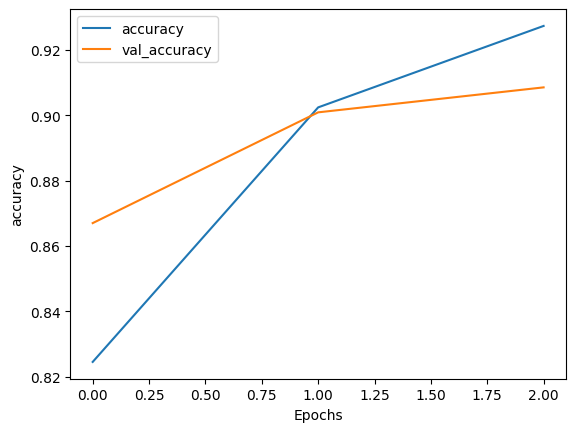

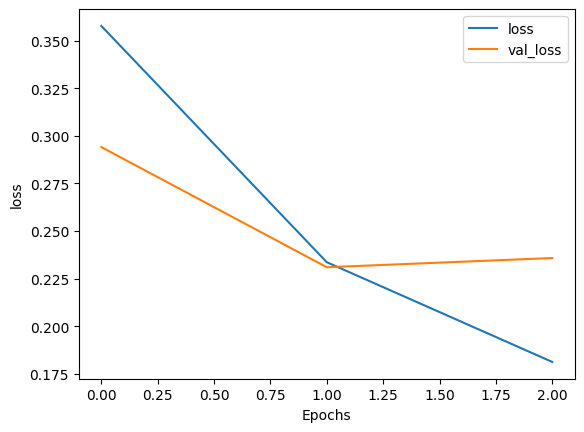

In [23]:
import matplotlib.pyplot as plt

def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

In [24]:
test, val = train_test_split(dev, test_size=dev_size, random_state=42)

In [25]:
dev.shape

(3008, 3)

In [26]:
test.head()

,S. No.,text,label
8373,1344,रिपोर्टर के बेतुके सवाल पर अमेरिका फेरेरा का ज...,0
11380,4351,जीवाश्म ईंधन को बढ़ावा देने वाले 7 मिथकों को ध...,0
9656,2627,लिंडसे ग्राहम ने ट्रंप को चेतावनी दी: म्यूएलर ...,0
373,373,नजरिया बदलो और पूरी स्थिति बदल जाएगी।,1
2507,2507,मुझे याद करना जब मै चला जाऊँ,1


In [27]:
test_encoded = bert_encode(dev.text)

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices(test_encoded)
    .batch(batch_size)
)

predicted_tweets = model.predict(test_dataset, batch_size=batch_size)
predicted_tweets_binary = tf.cast(tf.round(predicted_tweets), tf.int32).numpy().flatten()
print(predicted_tweets_binary)
#my_submission = pd.DataFrame({'id': dev.id, 'label': predicted_tweets_binary})
#my_submission.to_csv('my_submission.csv', index=False)

94/94 [==============================] - 26s 280ms/step
[0 0 0 ... 1 1 0]


In [28]:
from sklearn.metrics import accuracy_score
from sklearn import metrics

In [29]:
print("Bert+LSTM")
print("Accuracy score =", accuracy_score(dev['label'], predicted_tweets_binary))
print(metrics.classification_report(dev['label'], predicted_tweets_binary))


Bert+LSTM
Accuracy score = 0.9085771276595744
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      1811
           1       0.85      0.93      0.89      1197

    accuracy                           0.91      3008
   macro avg       0.90      0.91      0.91      3008
weighted avg       0.91      0.91      0.91      3008

